# Preprocessing, Training, and Evaluation - TrainPulse
Notebook ini difokuskan pada persiapan data, training beberapa model machine learning, dan evaluasi untuk memprediksi kelulusan training (status_lulus).

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load data
base_dir = os.path.dirname(os.path.abspath(''))
db_path = os.path.join(base_dir, 'data', 'trainpulse.db')

conn = sqlite3.connect(db_path)

query = '''
SELECT 
    tp.durasi_hari,
    a.pretest_score, a.status_lulus,
    (SELECT COUNT(*) FROM attendances att WHERE att.session_id = a.session_id AND att.participant_id = a.participant_id AND att.status_hadir = 1) * 1.0 / tp.durasi_hari AS attendance_rate
FROM assessments a
JOIN training_sessions ts ON a.session_id = ts.id
JOIN training_programs tp ON ts.program_id = tp.id
'''

df = pd.read_sql_query(query, conn)
conn.close()

df.head()

,durasi_hari,pretest_score,status_lulus,attendance_rate
0,3,40.88,1,1.000000
1,3,61.71,0,0.333333
2,3,79.06,1,0.333333
3,3,62.91,1,1.000000
4,3,79.41,1,0.666667


## Preprocessing & Data Splitting
Memisahkan fitur dan target, serta melakukan train-test split dengan stratifikasi karena kemungkinan kelas target tidak seimbang.

In [2]:
X = df[['attendance_rate', 'pretest_score', 'durasi_hari']]
y = df['status_lulus'].astype(int)

# Stratified split agar proporsi lulus/tidak lulus seimbang di train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Class distribution in Train:\n", y_train.value_counts(normalize=True))

Training data shape: (1135, 3)
Testing data shape: (284, 3)
Class distribution in Train:
 status_lulus
1    0.511894
0    0.488106
Name: proportion, dtype: float64


## Model Training: Logistic Regression vs Random Forest
Kita akan menggunakan Pipeline untuk memastikan scaling (StandardScaler) diterapkan dengan benar tanpa data leakage.

In [3]:
# Pipeline 1: Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=42, class_weight='balanced'))
])

# Pipeline 2: Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


## Evaluation
Membandingkan kinerja kedua model menggunakan Confusion Matrix, Classification Report, dan ROC-AUC.

--- Evaluation for Logistic Regression ---
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       138
           1       0.85      0.82      0.84       146

    accuracy                           0.83       284
   macro avg       0.83      0.83      0.83       284
weighted avg       0.84      0.83      0.83       284

ROC-AUC Score: 0.9152



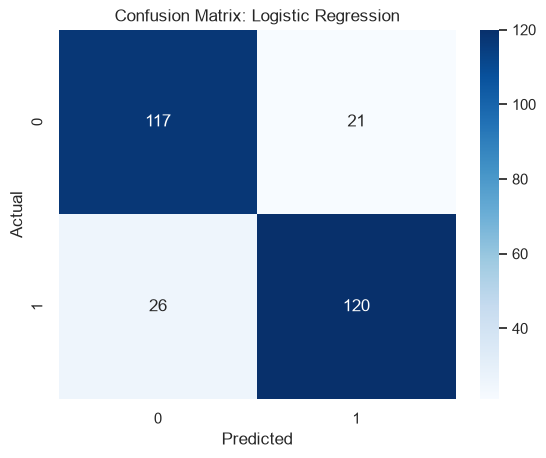

--- Evaluation for Random Forest ---
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.78      0.79       138
           1       0.80      0.83      0.81       146

    accuracy                           0.80       284
   macro avg       0.80      0.80      0.80       284
weighted avg       0.80      0.80      0.80       284

ROC-AUC Score: 0.8751



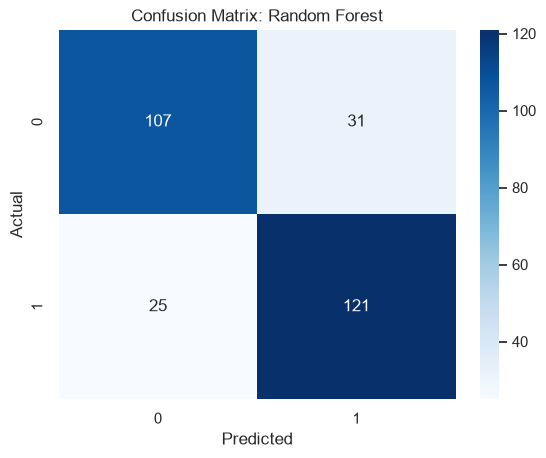

In [4]:
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"--- Evaluation for {name} ---")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n")
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(lr_pipeline, "Logistic Regression")
evaluate_model(rf_pipeline, "Random Forest")

**Insight Evaluasi:**
- Random Forest biasanya sedikit lebih unggul dalam menangani interaksi antar fitur yang kompleks.
- Logistic Regression memberikan hasil yang mudah diinterpretasikan.
- Kita akan menyimpan Random Forest sebagai model final (atau yang memiliki skor ROC-AUC / F1 tertinggi).

## Exporting Final Model
Menyimpan model terbaik beserta preprocessing step-nya ke file `.pkl` menggunakan `joblib`.

In [5]:
artifacts_dir = os.path.join(base_dir, 'ml', 'artifacts')
os.makedirs(artifacts_dir, exist_ok=True)
model_path = os.path.join(artifacts_dir, 'model.pkl')

# Misalkan kita memilih RandomForest
joblib.dump(rf_pipeline, model_path)
print(f"Final model saved to {model_path}")

Final model saved to /Users/mymac/anaconda_projects/kumpulan_project_b/TrainPulse/ml/artifacts/model.pkl
